#Libraries


In [1]:
!git clone -b feature/cv-yolo-detection https://github.com/Govind-2004/AI_Adaptive_Traffic_Analysis_and_Signal_Optimization.git

Cloning into 'AI_Adaptive_Traffic_Analysis_and_Signal_Optimization'...
remote: Enumerating objects: 87, done.
remote: Counting objects: 100% (87/87), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 87 (delta 28), reused 36 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (87/87), 2.96 MiB | 26.34 MiB/s, done.
Resolving deltas: 100% (28/28), done.


In [2]:
%cd /content/AI_Adaptive_Traffic_Analysis_and_Signal_Optimization

/content/AI_Adaptive_Traffic_Analysis_and_Signal_Optimization


In [3]:
# Install ByteTrack dependency
!pip install -q lap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 31.7 MB/s eta 0:00:00


In [4]:
# Install required packages
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 8.0 MB/s eta 0:00:00


In [5]:
# Import libraries required for traffic metric analysis
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib.util
import os
import cv2
import sys



# Locate racking Data


In [6]:
# Project root directory
repo_path = "/content/AI_Adaptive_Traffic_Analysis_and_Signal_Optimization"

# Expected tracking data location
tracking_data_path = os.path.join(repo_path, "cv", "output", "tracking_data.csv")

print("Tracking data path:")
print(tracking_data_path)


Tracking data path:
/content/AI_Adaptive_Traffic_Analysis_and_Signal_Optimization/cv/output/tracking_data.csv


In [7]:
# Locate tracking_data.csv if it is not at the expected path
found_path = None

if os.path.exists(tracking_data_path):
    found_path = tracking_data_path
else:
    print("Tracking data not found at the expected location. Searching /content ...")
    for root, dirs, files in os.walk("/content"):
        if "tracking_data.csv" in files:
            found_path = os.path.join(root, "tracking_data.csv")
            break

if found_path:
    tracking_data_path = found_path
    print("Tracking data found:", tracking_data_path)
else:
    print("tracking_data.csv not found anywhere. Will generate it in the next cell.")

Tracking data not found at the expected location. Searching /content ...
tracking_data.csv not found anywhere. Will generate it in the next cell.


In [8]:
detector_path = "/content/AI_Adaptive_Traffic_Analysis_and_Signal_Optimization/cv/detection/detector.py"

print("Exists:", os.path.exists(detector_path))

spec = importlib.util.spec_from_file_location(
    "detector_module",
    detector_path
)

detector = importlib.util.module_from_spec(spec)

spec.loader.exec_module(detector)

print("SUCCESS!")
print(detector.VEHICLE_CLASSES)

Exists: True
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
SUCCESS!
{2: 'car', 3: 'motorcycle', 5: 'bus', 7: 'truck'}


In [9]:
# GENERATE TRACKING DATA
# YOLO Vehicle Detection + ByteTrack

if found_path is None:

    print("Starting tracking-data generation...")

    # Load YOLO model
    model, device = detector.load_model()

    print("YOLO model loaded successfully.")
    print("Running on:", device)
    print("Vehicle classes:", detector.VEHICLE_CLASSES)

    # Mount Google Drive
    from google.colab import drive

    drive.mount("/content/drive")

    #  Define traffic video path
    video_path = os.path.join(
        "/content/drive/MyDrive/Colab Notebooks/Datasets /Capstone_traffic/Demo",
        "854671-hd_1920_1080_25fps.mp4"
    )

    print("\nVideo path:")
    print(video_path)

    # Check whether video exists
    if not os.path.exists(video_path):
        raise FileNotFoundError(
            f"\nTraffic video not found:\n{video_path}"
        )

    print("Video file found.")

    #  Open video and read basic information
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise RuntimeError(
            "Could not open the traffic video."
        )

    total_frames = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    fps = cap.get(cv2.CAP_PROP_FPS)

    width = int(
        cap.get(cv2.CAP_PROP_FRAME_WIDTH)
    )

    height = int(
        cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
    )

    print("\nVideo information:")
    print("Resolution:", width, "x", height)
    print("FPS:", fps)
    print("Total frames:", total_frames)

    cap.release()

    #  Start YOLO + ByteTrack
    print("\nStarting YOLO + ByteTrack processing...")
    print("This may take some time.")

    results = model.track(
        source=video_path,

        # Detect only vehicle classes
        classes=list(
            detector.VEHICLE_CLASSES.keys()
        ),

        # Minimum detection confidence
        conf=0.35,

        # ByteTrack tracker
        tracker="bytetrack.yaml",

        # Maintain tracking IDs
        persist=True,

        # Process results frame by frame
        stream=True,

        # Disable unnecessary console output
        verbose=False
    )

    #  Create storage for tracking data
    tracking_data = []

    frame_count = 0
    #  Process every frame
    for r in results:

        # Check whether ByteTrack assigned IDs
        if r.boxes.id is not None:

            # Process every tracked vehicle
            for box, track_id in zip(
                r.boxes,
                r.boxes.id
            ):

                # Tracking ID
                track_id = int(track_id)

                # Vehicle class
                class_id = int(box.cls[0])

                cls_name = detector.VEHICLE_CLASSES[
                    class_id
                ]

                # Bounding-box coordinates
                x1, y1, x2, y2 = (
                    box.xyxy[0]
                    .cpu()
                    .numpy()
                )

                # Calculate vehicle center point
                center_x = (x1 + x2) / 2
                center_y = (y1 + y2) / 2

                # Store tracking information
                tracking_data.append({
                    "frame": frame_count,
                    "track_id": track_id,
                    "class": cls_name,
                    "center_x": center_x,
                    "center_y": center_y
                })

        # Move to next frame
        frame_count += 1

        # Display progress every 100 frames
        if frame_count % 100 == 0:
            print(
                f"Processed "
                f"{frame_count}/{total_frames} frames"
            )


    #  Convert tracking data to DataFrame
    df_generated = pd.DataFrame(
        tracking_data
    )

    print("\n========================================")
    print("TRACKING PROCESS COMPLETED")
    print("========================================")

    print("Frames processed:", frame_count)
    print("Tracking records:", len(df_generated))

    #  Validate generated data
    if df_generated.empty:
        raise RuntimeError(
            "No tracking data was generated. "
            "Check the video and YOLO settings."
        )

    # Check required columns
    required_columns = [
        "frame",
        "track_id",
        "class",
        "center_x",
        "center_y"
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in df_generated.columns
    ]

    if missing_columns:
        raise RuntimeError(
            f"Missing columns: {missing_columns}"
        )

    #  Display tracking statistics
    unique_vehicles = (
        df_generated["track_id"].nunique()
    )

    print(
        "Unique tracked vehicles:",
        unique_vehicles
    )

    print("\nVehicle classes detected:")

    print(
        df_generated["class"].value_counts()
    )

    #  Save tracking data
    os.makedirs(
        os.path.dirname(tracking_data_path),
        exist_ok=True
    )

    df_generated.to_csv(
        tracking_data_path,
        index=False
    )

    print("\nTracking data saved successfully:")
    print(tracking_data_path)

    #  Display first few records
    print("\nFirst 5 tracking records:")

    display(
        df_generated.head()
    )

else:

    print(
        "Skipping generation - "
        "tracking_data.csv already found."
    )

Starting tracking-data generation...
YOLO model loaded successfully.
Running on: cuda
Vehicle classes: {2: 'car', 3: 'motorcycle', 5: 'bus', 7: 'truck'}
Mounted at /content/drive

Video path:
/content/drive/MyDrive/Colab Notebooks/Datasets /Capstone_traffic/Demo/854671-hd_1920_1080_25fps.mp4
Video file found.

Video information:
Resolution: 1920 x 1080
FPS: 25.0
Total frames: 1501

Starting YOLO + ByteTrack processing...
This may take some time.
Processed 100/1501 frames
Processed 200/1501 frames
Processed 300/1501 frames
Processed 400/1501 frames
Processed 500/1501 frames
Processed 600/1501 frames
Processed 700/1501 frames
Processed 800/1501 frames
Processed 900/1501 frames
Processed 1000/1501 frames
Processed 1100/1501 frames
Processed 1200/1501 frames
Processed 1300/1501 frames
Processed 1400/1501 frames
Processed 1500/1501 frames

TRACKING PROCESS COMPLETED
Frames processed: 1501
Tracking records: 8893
Unique tracked vehicles: 224

Vehicle classes detected:
class
car           6435

,frame,track_id,class,center_x,center_y
0,0,1,car,1348.632568,565.079163
1,0,2,bus,1001.883911,376.222595
2,0,3,car,753.644043,492.731720
3,0,4,car,1035.102051,964.630737
4,0,5,car,922.093140,672.220154


#Load Tracking Data



In [10]:
# Load the tracking dataset
df = pd.read_csv(tracking_data_path)

print("Tracking data loaded successfully.")
print("Number of records:", len(df))


Tracking data loaded successfully.
Number of records: 8893


## Inspect Tracking Dataset


In [11]:
# Inspect dataset dimensions and sample records
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst five records:")
display(df.head())


Dataset shape: (8893, 5)

Column names:
['frame', 'track_id', 'class', 'center_x', 'center_y']

First five records:


,frame,track_id,class,center_x,center_y
0,0,1,car,1348.63260,565.07916
1,0,2,bus,1001.88390,376.22260
2,0,3,car,753.64404,492.73172
3,0,4,car,1035.10200,964.63074
4,0,5,car,922.09314,672.22015


#### Validate Required Columns


In [12]:
# Required columns for traffic metric calculation
required_columns = ["frame", "track_id", "class", "center_x", "center_y"]
missing_columns = [c for c in required_columns if c not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")
print("All required columns are available.")


All required columns are available.


### Check Missing Values and Data Types


In [13]:
# Check data types and missing values
print("Data types:")
print(df.dtypes)
print("\nMissing values:")
print(df[required_columns].isnull().sum())


Data types:
frame         int64
track_id      int64
class        object
center_x    float64
center_y    float64
dtype: object

Missing values:
frame       0
track_id    0
class       0
center_x    0
center_y    0
dtype: int64


##  Tracking Statistics




In [14]:
# Calculate basic tracking statistics
total_frames = df["frame"].nunique()
total_tracked_vehicles = df["track_id"].nunique()

print("Total frames containing tracking data:", total_frames)
print("Total unique tracked vehicles:", total_tracked_vehicles)


Total frames containing tracking data: 1501
Total unique tracked vehicles: 224


### Vehicle Class Distribution


In [15]:
# Count unique tracked vehicles by vehicle class
class_distribution = (
    df.groupby("class")["track_id"]
      .nunique()
      .reset_index(name="vehicle_count")
)

display(class_distribution)


,class,vehicle_count
0,bus,11
1,car,146
2,motorcycle,2
3,truck,150


### Vehicle Class Visualization


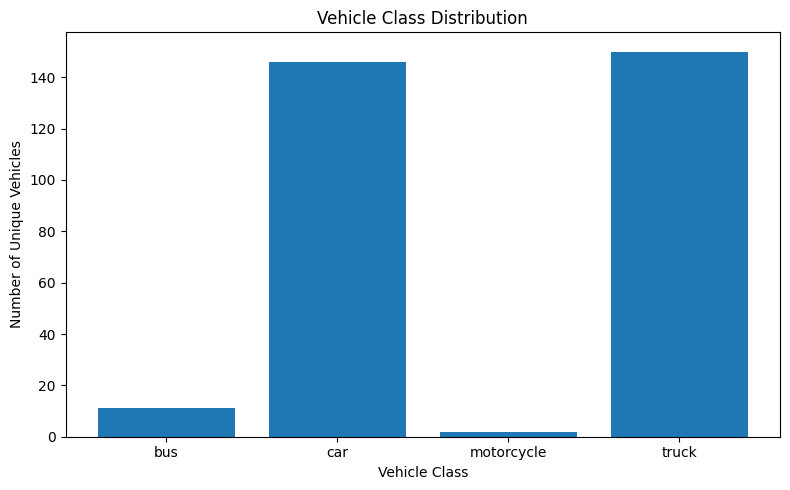

In [16]:
# Plot unique vehicles by class
plt.figure(figsize=(8, 5))
plt.bar(class_distribution["class"].astype(str), class_distribution["vehicle_count"])
plt.xlabel("Vehicle Class")
plt.ylabel("Number of Unique Vehicles")
plt.title("Vehicle Class Distribution")
plt.tight_layout()
plt.show()


## Vehicle Count Per Frame



In [17]:
# Calculate the number of unique vehicles present in each frame
frame_counts = (
    df.groupby("frame")["track_id"]
      .nunique()
      .reset_index(name="vehicle_count")
)

print("Frame-wise vehicle counts calculated successfully.")
display(frame_counts.head(10))


Frame-wise vehicle counts calculated successfully.


,frame,vehicle_count
0,0,10
1,1,8
2,2,8
3,3,9
4,4,9
5,5,9
6,6,11
7,7,13
8,8,12
9,9,12


###  Vehicle Count Statistics


In [18]:
# Calculate summary statistics for frame-wise vehicle count
display(frame_counts["vehicle_count"].describe())


,vehicle_count
count,1501.000000
mean,5.924717
std,1.864134
min,2.000000
25%,5.000000
50%,6.000000
75%,7.000000
max,13.000000


### Vehicle Count Over Time


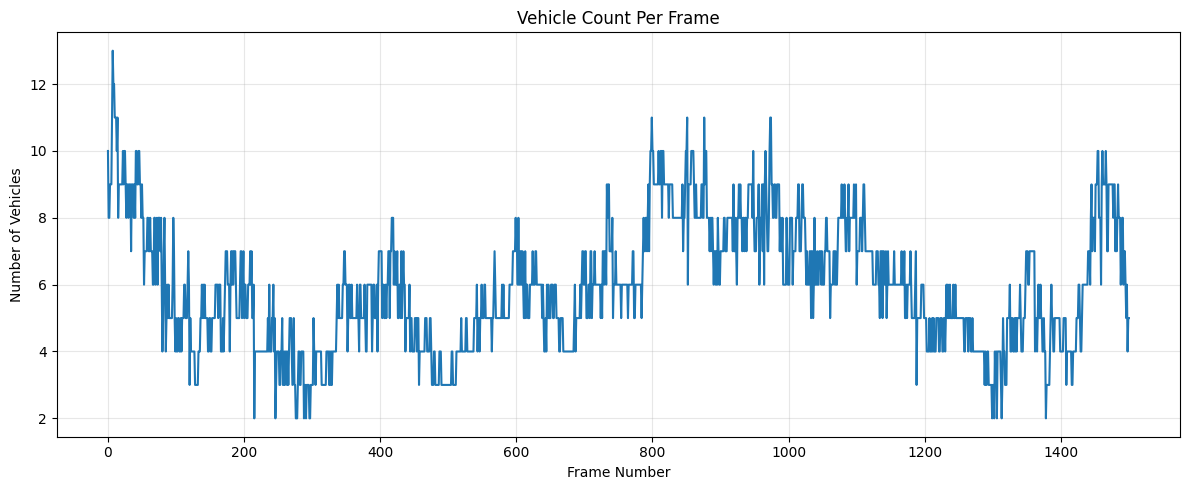

In [19]:
# Plot vehicle count for each frame
plt.figure(figsize=(12, 5))
plt.plot(frame_counts["frame"], frame_counts["vehicle_count"])
plt.xlabel("Frame Number")
plt.ylabel("Number of Vehicles")
plt.title("Vehicle Count Per Frame")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Smoothed Vehicle Count



In [20]:
# Calculate a moving average to smooth short-term fluctuations
window_size = 15
frame_counts["smoothed_count"] = frame_counts["vehicle_count"].rolling(window=window_size, min_periods=1).mean()
display(frame_counts.head())


,frame,vehicle_count,smoothed_count
0,0,10,10.000000
1,1,8,9.000000
2,2,8,8.666667
3,3,9,8.750000
4,4,9,8.800000


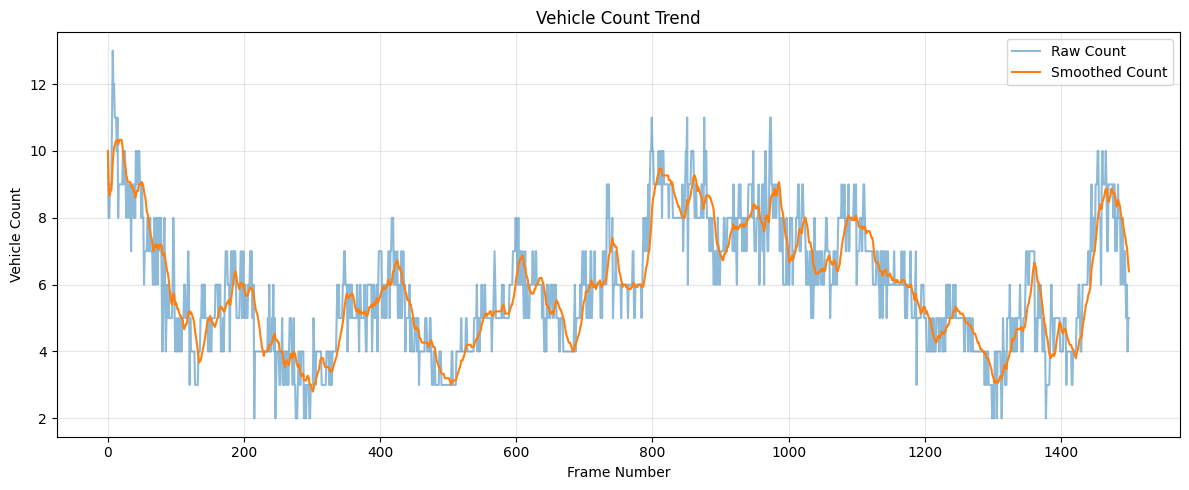

In [21]:
# Plot raw and smoothed vehicle counts
plt.figure(figsize=(12, 5))
plt.plot(frame_counts["frame"], frame_counts["vehicle_count"], label="Raw Count", alpha=0.5)
plt.plot(frame_counts["frame"], frame_counts["smoothed_count"], label="Smoothed Count")
plt.xlabel("Frame Number")
plt.ylabel("Vehicle Count")
plt.title("Vehicle Count Trend")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


##  Vehicle Count by Class Per Frame


In [22]:
# Calculate unique tracked vehicle counts by class for every frame
class_frame_counts = (
    df.groupby(["frame", "class"])["track_id"]
      .nunique()
      .reset_index(name="count")
)
display(class_frame_counts.head(10))


,frame,class,count
0,0,bus,2
1,0,car,7
2,0,truck,1
3,1,bus,1
4,1,car,7
5,2,bus,1
6,2,car,7
7,3,bus,2
8,3,car,7
9,4,bus,2


### Create Frame-wise Vehicle Class Table


In [23]:
# Convert vehicle classes into separate columns
class_frame_table = (
    class_frame_counts.pivot(index="frame", columns="class", values="count")
    .fillna(0).reset_index()
)
display(class_frame_table.head())


class,frame,bus,car,motorcycle,truck
0,0,2.0,7.0,0.0,1.0
1,1,1.0,7.0,0.0,0.0
2,2,1.0,7.0,0.0,0.0
3,3,2.0,7.0,0.0,0.0
4,4,2.0,7.0,0.0,0.0


## Traffic Composition




In [24]:
# Calculate percentage composition of tracked vehicle classes
total_class_vehicles = class_distribution["vehicle_count"].sum()
class_distribution["percentage"] = class_distribution["vehicle_count"] / total_class_vehicles * 100
display(class_distribution)


,class,vehicle_count,percentage
0,bus,11,3.559871
1,car,146,47.249191
2,motorcycle,2,0.647249
3,truck,150,48.543689


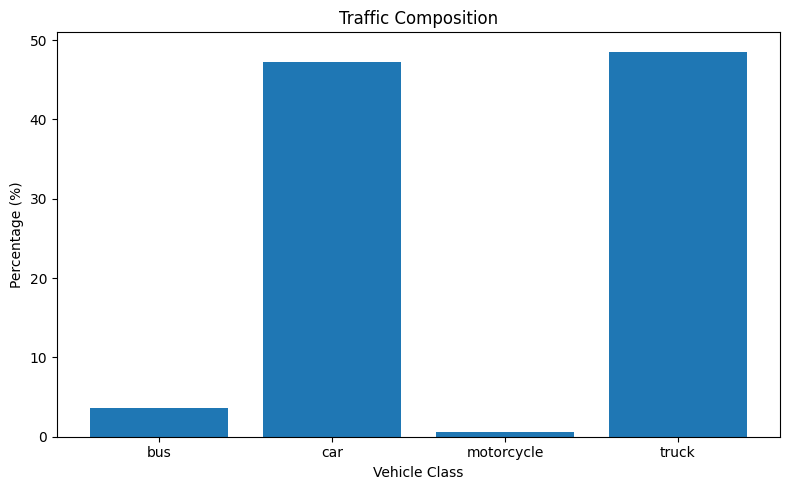

In [25]:
# Visualize traffic composition
plt.figure(figsize=(8, 5))
plt.bar(class_distribution["class"].astype(str), class_distribution["percentage"])
plt.xlabel("Vehicle Class")
plt.ylabel("Percentage (%)")
plt.title("Traffic Composition")
plt.tight_layout()
plt.show()


##  Vehicle Trajectory Analysis




In [26]:
# Sort observations by vehicle ID and frame
trajectory_df = df.sort_values(by=["track_id", "frame"]).copy()
display(trajectory_df.head(10))


,frame,track_id,class,center_x,center_y
0,0,1,car,1348.6326,565.07916
10,1,1,car,1355.2588,570.17800
18,2,1,car,1361.1165,574.14720
26,3,1,car,1368.6697,580.53530
35,4,1,car,1377.3251,586.59310
44,5,1,car,1383.2717,591.57434
53,6,1,car,1390.6392,596.20970
64,7,1,car,1397.9331,601.07910
77,8,1,car,1406.4849,607.74340
89,9,1,car,1413.8608,613.23425


### Inspect an Individual Vehicle Trajectory


In [27]:
# Select the first available vehicle ID
sample_track_id = trajectory_df["track_id"].iloc[0]
vehicle_trajectory = trajectory_df[trajectory_df["track_id"] == sample_track_id]
print("Selected Track ID:", sample_track_id)
print("Number of observations:", len(vehicle_trajectory))
display(vehicle_trajectory.head())


Selected Track ID: 1
Number of observations: 66


,frame,track_id,class,center_x,center_y
0,0,1,car,1348.6326,565.07916
10,1,1,car,1355.2588,570.17800
18,2,1,car,1361.1165,574.14720
26,3,1,car,1368.6697,580.53530
35,4,1,car,1377.3251,586.59310


###  Plot Vehicle Trajectory


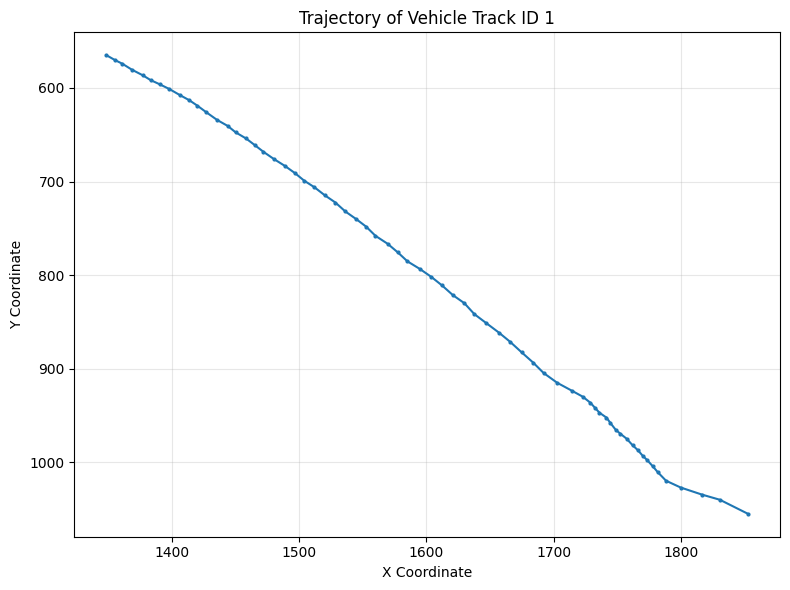

In [28]:
# Plot the trajectory of one tracked vehicle
plt.figure(figsize=(8, 6))
plt.plot(vehicle_trajectory["center_x"], vehicle_trajectory["center_y"], marker="o", markersize=2)
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.title(f"Trajectory of Vehicle Track ID {sample_track_id}")
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Vehicle Movement Analysis



In [29]:
# Calculate frame-to-frame coordinate changes for each tracked vehicle
trajectory_df["delta_x"] = trajectory_df.groupby("track_id")["center_x"].diff()
trajectory_df["delta_y"] = trajectory_df.groupby("track_id")["center_y"].diff()

# Calculate displacement in pixels
trajectory_df["pixel_displacement"] = np.sqrt(trajectory_df["delta_x"] ** 2 + trajectory_df["delta_y"] ** 2)

display(trajectory_df[["frame", "track_id", "center_x", "center_y", "pixel_displacement"]].head(10))


,frame,track_id,center_x,center_y,pixel_displacement
0,0,1,1348.6326,565.07916,NaN
10,1,1,1355.2588,570.17800,8.360903
18,2,1,1361.1165,574.14720,7.075818
26,3,1,1368.6697,580.53530,9.892353
35,4,1,1377.3251,586.59310,10.564700
44,5,1,1383.2717,591.57434,7.757242
53,6,1,1390.6392,596.20970,8.704402
64,7,1,1397.9331,601.07910,8.769951
77,8,1,1406.4849,607.74340,10.841872
89,9,1,1413.8608,613.23425,9.195289


### Average Pixel Movement


In [30]:
# Calculate average frame-to-frame displacement
average_pixel_displacement = trajectory_df["pixel_displacement"].dropna().mean()
print("Average frame-to-frame displacement:", round(average_pixel_displacement, 2), "pixels")


Average frame-to-frame displacement: 5.09 pixels


In [31]:
!ls cv/traffic/

count.py  __init__.py


In [32]:
# Testing count.py

sys.path.insert(
    0,
    "/content/AI_Adaptive_Traffic_Analysis_and_Signal_Optimization/cv"
)

from traffic.count import count_vehicles, class_distribution

print("count.py imported successfully!")

count.py imported successfully!


In [33]:
frame_counts, class_frame_counts = count_vehicles(df)

print("Frame-wise vehicle counts:")
display(frame_counts.head(10))

print("Class-wise vehicle counts:")
display(class_frame_counts.head(10))

print("Overall class distribution:")
display(class_distribution(df))

Frame-wise vehicle counts:


,frame,vehicle_count
0,0,10
1,1,8
2,2,8
3,3,9
4,4,9
5,5,9
6,6,11
7,7,13
8,8,12
9,9,12


Class-wise vehicle counts:


class,frame,bus,car,motorcycle,truck
0,0,2.0,7.0,0.0,1.0
1,1,1.0,7.0,0.0,0.0
2,2,1.0,7.0,0.0,0.0
3,3,2.0,7.0,0.0,0.0
4,4,2.0,7.0,0.0,0.0
5,5,2.0,7.0,0.0,0.0
6,6,2.0,8.0,0.0,1.0
7,7,2.0,9.0,0.0,2.0
8,8,1.0,9.0,0.0,2.0
9,9,1.0,9.0,0.0,2.0


Overall class distribution:


,class,vehicle_count
0,bus,11
1,car,146
2,motorcycle,2
3,truck,150
